# Pronóstico a 24h de PM2.5 en Pekín — Matriz de correlaciones

**Proyecto de Aprendizaje Automático en Series Temporales y Flujos de Datos**

Este cuaderno muestra la **matriz de correlaciones** entre las variables del dataset `../data/processed/beijing_data_huecos_24h.csv`, generado en `04_preparacion_datos_prediccion.ipynb`. Las variables exógenas están desplazadas 24h (`*_obs_24`, `*_trend_24_30`), por lo que la correlación con `pm2.5` indica su utilidad como predictores a 24h.

`pm2.5` conserva huecos (NaN); las correlaciones se calculan por pares, descartando solo las filas con NaN en cada par.

## 1. Carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/beijing_data_huecos_24h.csv', index_col='datetime', parse_dates=True)
print(df.shape)
print("NaN en pm2.5:", df['pm2.5'].isna().sum())
df.head()

(43794, 18)
NaN en pm2.5: 1463


,pm2.5,cal_sen_hora,cal_cos_hora,cal_sen_dia,cal_cos_dia,cal_sen_mes,cal_cos_mes,DEWP_obs_24,TEMP_obs_24,PRES_obs_24,Iws_obs_24,Is_obs_24,Ir_obs_24,viento_NE_obs_24,viento_NW_obs_24,viento_SE_obs_24,TEMP_trend_24_30,PRES_trend_24_30
datetime,,,,,,,,,,,,,,,,,,
2010-01-02 06:00:00,105.0,1.000000,6.123234e-17,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,19.23,0.0,0.0,0,1,0,2.0,-4.0
2010-01-02 07:00:00,124.0,0.965926,-2.588190e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,21.02,0.0,0.0,0,1,0,3.0,-3.0
2010-01-02 08:00:00,120.0,0.866025,-5.000000e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-9.0,1017.0,24.15,0.0,0.0,0,1,0,2.0,-2.0
2010-01-02 09:00:00,132.0,0.707107,-7.071068e-01,-0.974928,-0.222521,0.0,1.0,-20.0,-8.0,1017.0,27.28,0.0,0.0,0,1,0,6.0,-2.0
2010-01-02 10:00:00,140.0,0.500000,-8.660254e-01,-0.974928,-0.222521,0.0,1.0,-19.0,-7.0,1017.0,31.30,0.0,0.0,0,1,0,5.0,-1.0


## 2. Función de ploteo

In [2]:
def plot_corr(corr, titulo):
    n = len(corr)
    fig, ax = plt.subplots(figsize=(13, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # solo triángulo inferior
    im = ax.imshow(np.ma.masked_array(corr, mask), cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n), corr.columns, rotation=60, ha='right')
    ax.set_yticks(range(n), corr.columns)
    for i in range(n):
        for j in range(i + 1):
            v = corr.iloc[i, j]
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.6 else 'black')
    ax.spines[:].set_visible(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label='Correlación')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

## 3. Correlación de Pearson

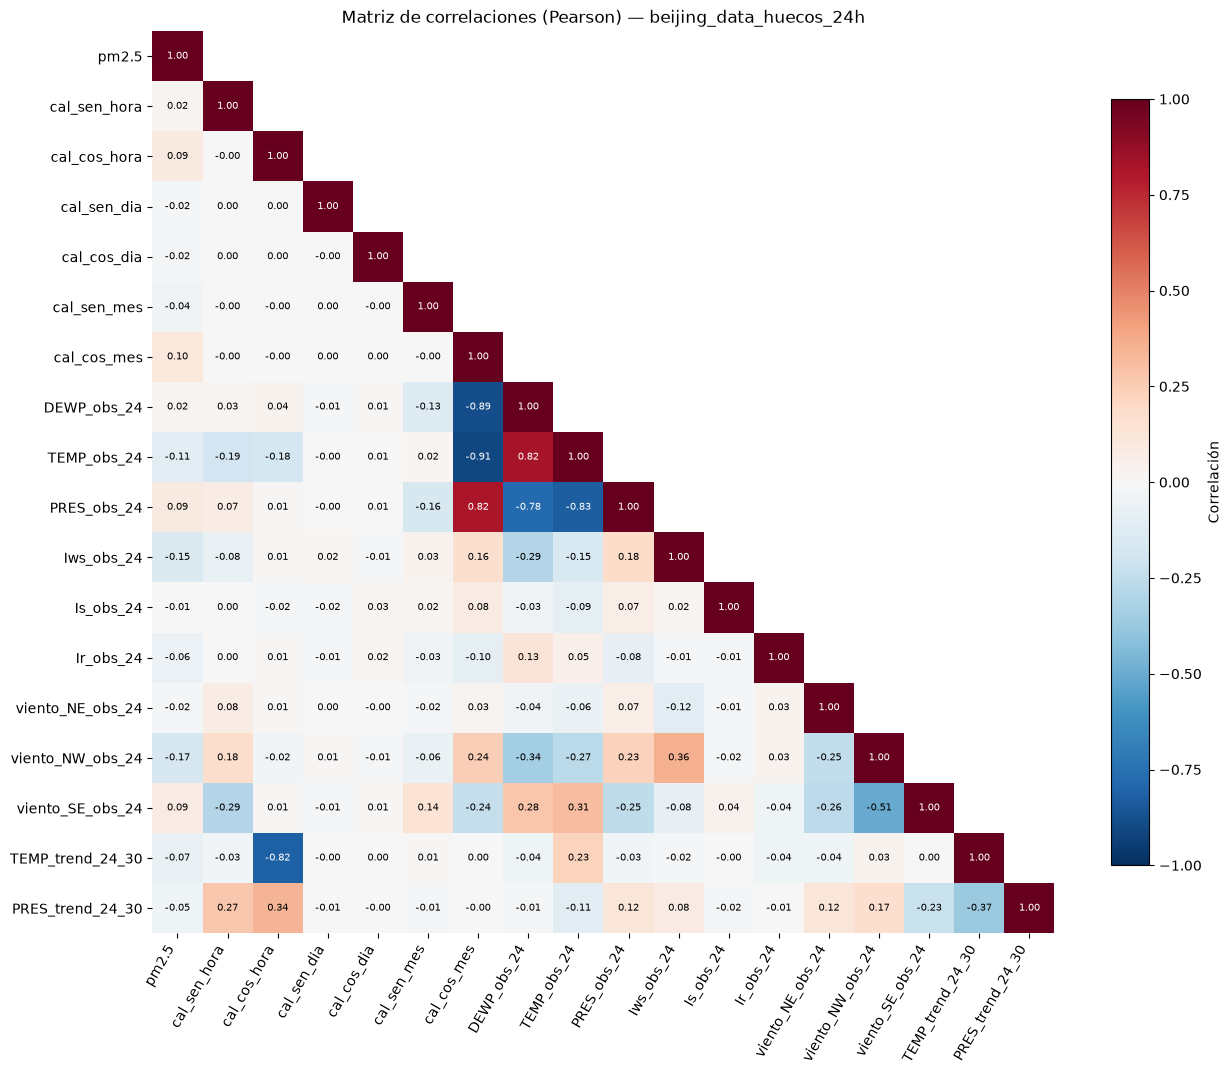

In [3]:
corr_pearson = df.corr(method='pearson')
plot_corr(corr_pearson, 'Matriz de correlaciones (Pearson) — beijing_data_huecos_24h')

## 4. Correlación de Spearman

`pm2.5` es muy asimétrica y `Iws`, `Is`, `Ir` tienen colas largas, así que Spearman (basada en rangos) recoge mejor relaciones monótonas no lineales.

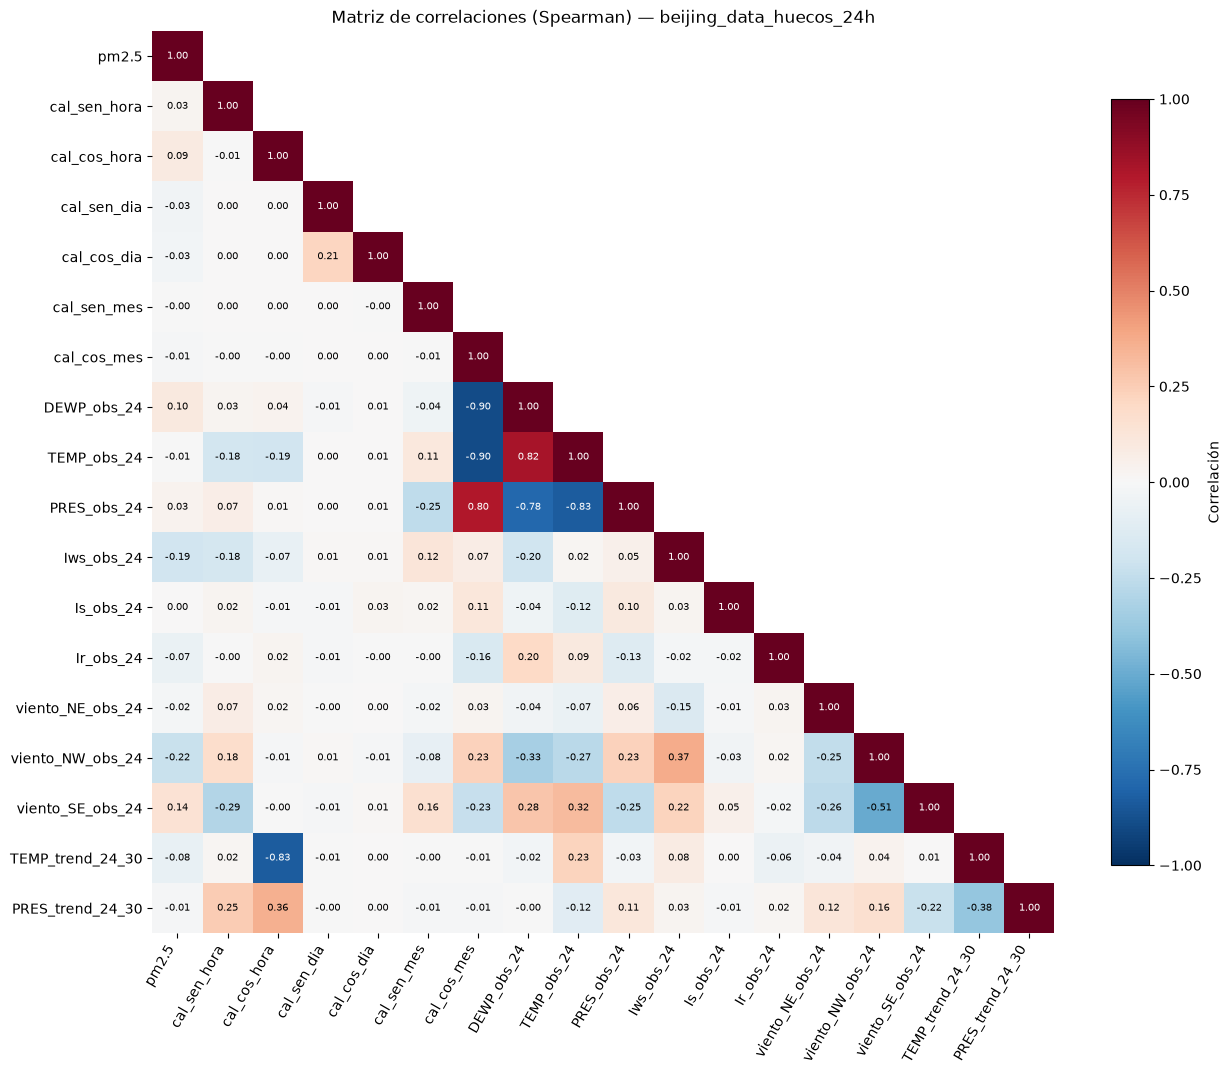

In [4]:
corr_spearman = df.corr(method='spearman')
plot_corr(corr_spearman, 'Matriz de correlaciones (Spearman) — beijing_data_huecos_24h')

## 5. Correlación de cada variable con `pm2.5`

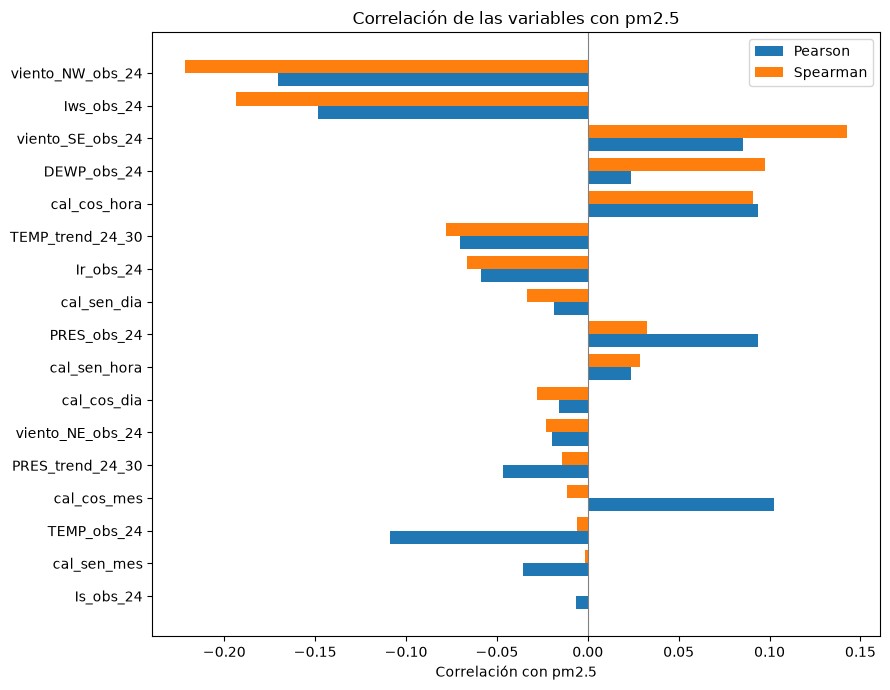

,pearson,spearman
viento_NW_obs_24,-0.170,-0.221
Iws_obs_24,-0.148,-0.194
viento_SE_obs_24,0.086,0.143
DEWP_obs_24,0.024,0.098
cal_cos_hora,0.093,0.091
TEMP_trend_24_30,-0.070,-0.078
Ir_obs_24,-0.059,-0.066
cal_sen_dia,-0.019,-0.034
PRES_obs_24,0.094,0.033
cal_sen_hora,0.024,0.029


In [5]:
corr_target = pd.DataFrame({
    'pearson': corr_pearson['pm2.5'],
    'spearman': corr_spearman['pm2.5'],
}).drop('pm2.5').sort_values('spearman', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(corr_target))
ax.barh(y - 0.2, corr_target['pearson'], height=0.4, label='Pearson')
ax.barh(y + 0.2, corr_target['spearman'], height=0.4, label='Spearman')
ax.set_yticks(y, corr_target.index)
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('Correlación con pm2.5')
ax.set_title('Correlación de las variables con pm2.5')
ax.legend()
plt.tight_layout()
plt.show()

corr_target.sort_values('spearman', key=abs, ascending=False).round(3)